In [1]:
import os

# 1) Where the extracted folder "001" lives (it must contain subfolders 0001, 0002, ...)
DATA_001_DIR = os.path.abspath("001")   # change if needed, e.g. "/kaggle/input/.../001"

# 2) Your targets file (must have: group_id,target_name)
TARGETS_CSV = os.path.abspath("target_50.csv")  # change if needed

# 3) Where to write masks + pairs
MASK_ROOT = os.path.abspath("mask/001")
PAIRS_CSV = os.path.abspath("pairs_50.csv")

print("DATA_001_DIR:", DATA_001_DIR)
print("TARGETS_CSV:", TARGETS_CSV)
print("MASK_ROOT:", MASK_ROOT)
print("PAIRS_CSV:", PAIRS_CSV)

DATA_001_DIR: /home/jovyan/001
TARGETS_CSV: /home/jovyan/target_50.csv
MASK_ROOT: /home/jovyan/mask/001
PAIRS_CSV: /home/jovyan/pairs_50.csv


In [2]:
import os
import pandas as pd

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

targets_df = pd.read_csv(TARGETS_CSV)

rows = []
for _, r in targets_df.iterrows():
    group_id = str(r["group_id"]).strip().replace(".0", "").zfill(4)
    target_name = str(r["target_name"]).strip()
    target_norm = target_name.lower()

    group_dir = os.path.join(DATA_001_DIR, group_id)
    if not os.path.isdir(group_dir):
        raise FileNotFoundError(f"Group folder missing: {group_dir}")

    files = [f for f in os.listdir(group_dir) if f.lower().endswith(IMAGE_EXTS)]
    if len(files) == 0:
        raise RuntimeError(f"No images in: {group_dir}")

    matches = [f for f in files if f.strip().lower() == target_norm]
    if len(matches) != 1:
        raise RuntimeError(f"{group_id}: target '{target_name}' matched {len(matches)} files")

    target_file = matches[0]
    target_path = os.path.join(group_dir, target_file)

    for fname in files:
        role = "target" if fname.strip().lower() == target_norm else "input"
        rows.append({
            "group_id": group_id,
            "image_path": os.path.join(group_dir, fname),
            "role": role,
            "target_path": target_path
        })

pairs_df = pd.DataFrame(rows)
pairs_df.to_csv(PAIRS_CSV, index=False)

print("pairs rows:", len(pairs_df))
print("unique groups:", pairs_df["group_id"].nunique())
print("target rows:", (pairs_df["role"] == "target").sum())
print("saved:", PAIRS_CSV)

pairs rows: 5400
unique groups: 50
target rows: 50
saved: /home/jovyan/pairs_50.csv


In [6]:
%pip install opencv-python scikit-image

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 101.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import cv2
import numpy as np
from skimage.filters import threshold_sauvola

os.makedirs(MASK_ROOT, exist_ok=True)

SAUVOLA_WINDOW = 41
SAUVOLA_K = 0.2
CLOSE_KERNEL = 3
DILATE_KERNEL = 1

def make_mask_from_target(target_path):
    gray = cv2.imread(target_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Cannot read: {target_path}")

    g = gray.astype(np.float32) / 255.0
    t = threshold_sauvola(g, window_size=SAUVOLA_WINDOW, k=SAUVOLA_K)
    bw = (g < t).astype(np.uint8)  # 1 = ink
    mask = (bw * 255).astype(np.uint8)

    if CLOSE_KERNEL > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (CLOSE_KERNEL, CLOSE_KERNEL))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    if DILATE_KERNEL > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (DILATE_KERNEL, DILATE_KERNEL))
        mask = cv2.dilate(mask, k, iterations=1)

    mask = (mask > 127).astype(np.uint8) * 255
    return mask

grp = pairs_df[["group_id", "target_path"]].drop_duplicates().sort_values("group_id")

for _, r in grp.iterrows():
    gid = r["group_id"]
    out_dir = os.path.join(MASK_ROOT, gid)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "mask.png")

    mask = make_mask_from_target(r["target_path"])
    cv2.imwrite(out_path, mask)

print("Masks created:", len(grp))
print("Mask root:", MASK_ROOT)

Masks created: 50
Mask root: /home/jovyan/mask/001


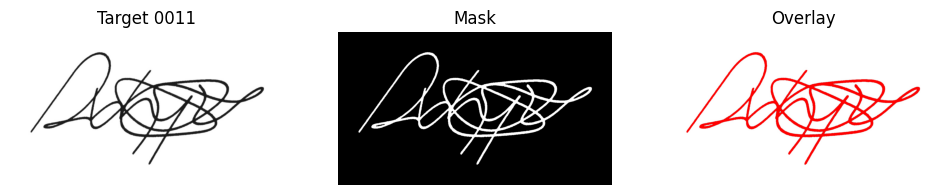

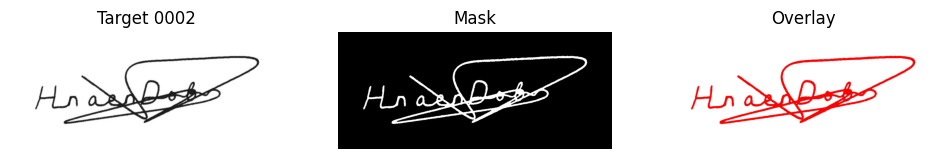

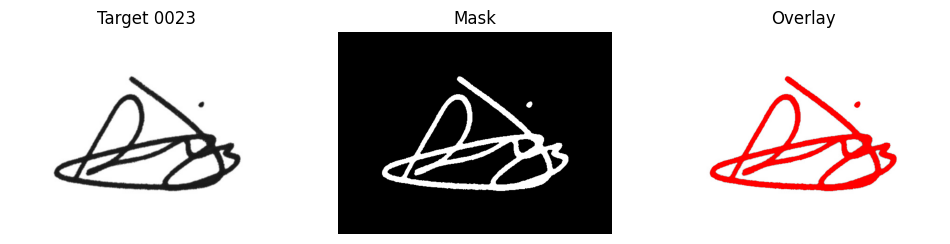

In [4]:
import matplotlib.pyplot as plt
import random
import pandas as pd
import cv2
import os

sample_groups = random.sample(sorted(grp["group_id"].tolist()), 3)

for gid in sample_groups:
    target_path = grp[grp["group_id"] == gid]["target_path"].iloc[0]
    mask_path = os.path.join(MASK_ROOT, gid, "mask.png")

    tgt = cv2.cvtColor(cv2.imread(target_path), cv2.COLOR_BGR2RGB)
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.title(f"Target {gid}"); plt.imshow(tgt); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(m, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay")
    overlay = tgt.copy()
    overlay[m > 0] = [255, 0, 0]
    plt.imshow(overlay); plt.axis("off")
    plt.show()

In [5]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf

# ------------ CONFIG ------------
IMG_SIZE = 256
BATCH_SIZE = 8
SEED = 42

N_TRAIN_GROUPS = 40
N_VAL_GROUPS = 5  # remaining -> test

AUTOTUNE = tf.data.AUTOTUNE
# --------------------------------

# If pairs_df is not in memory, uncomment:
# pairs_df = pd.read_csv(PAIRS_CSV)

# Train only on "input" images (never on the target images)
df = pairs_df[pairs_df["role"] == "input"].copy()
df["group_id"] = df["group_id"].astype(str).str.zfill(4)

# Attach mask paths: MASK_ROOT/<group_id>/mask.png
df["mask_path"] = df["group_id"].apply(lambda gid: os.path.join(MASK_ROOT, gid, "mask.png"))

# Sanity: masks exist?
missing = df[~df["mask_path"].apply(os.path.exists)]
if len(missing) > 0:
    raise FileNotFoundError(f"Missing masks. Example:\n{missing.head(3)}")

# ---------- Group-wise split (prevents leakage) ----------
groups = sorted(df["group_id"].unique().tolist())
rng = random.Random(SEED)
rng.shuffle(groups)

train_groups = set(groups[:N_TRAIN_GROUPS])
val_groups = set(groups[N_TRAIN_GROUPS:N_TRAIN_GROUPS + N_VAL_GROUPS])
test_groups = set(groups[N_TRAIN_GROUPS + N_VAL_GROUPS:])

train_df = df[df["group_id"].isin(train_groups)].reset_index(drop=True)
val_df   = df[df["group_id"].isin(val_groups)].reset_index(drop=True)
test_df  = df[df["group_id"].isin(test_groups)].reset_index(drop=True)

print("Samples total:", len(df))
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Groups:", len(train_groups), len(val_groups), len(test_groups))

# ---------- TF decoding ----------
def decode_rgb_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    return img

def decode_mask(path):
    m_bytes = tf.io.read_file(path)
    mask = tf.image.decode_image(m_bytes, channels=1, expand_animations=False)
    mask = tf.image.convert_image_dtype(mask, tf.float32)  # [0,1]
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")  # keep binary structure
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return mask

def make_dataset(frame, training: bool):
    img_paths = frame["image_path"].astype(str).tolist()
    mask_paths = frame["mask_path"].astype(str).tolist()
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    def _load(ip, mp):
        return decode_rgb_image(ip), decode_mask(mp)

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=min(len(frame), 2048), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

# ---------- Loss + Metrics ----------
def dice_loss(y_true, y_pred, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    dice = (2.0 * inter + eps) / (union + eps)
    return 1.0 - tf.reduce_mean(dice)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def _bin(y):  # threshold at 0.5 for metric computation
    return tf.where(y > 0.5, 1.0, 0.0)

def iou_coef(y_true, y_pred, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = _bin(tf.cast(y_pred, tf.float32))
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + eps) / (union + eps))

def precision_m(y_true, y_pred, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = _bin(tf.cast(y_pred, tf.float32))
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fp = tf.reduce_sum((1.0 - y_true) * y_pred, axis=[1,2,3])
    return tf.reduce_mean((tp + eps) / (tp + fp + eps))

def recall_m(y_true, y_pred, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = _bin(tf.cast(y_pred, tf.float32))
    tp = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    fn = tf.reduce_sum(y_true * (1.0 - y_pred), axis=[1,2,3])
    return tf.reduce_mean((tp + eps) / (tp + fn + eps))

def f1_m(y_true, y_pred, eps=1e-7):
    p = precision_m(y_true, y_pred, eps)
    r = recall_m(y_true, y_pred, eps)
    return (2.0 * p * r + eps) / (p + r + eps)

# ---------- U-Net model ----------
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x

def build_unet(input_shape=(256,256,3)):
    inputs = tf.keras.Input(shape=input_shape)

    c1 = conv_block(inputs, 32);  p1 = tf.keras.layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);      p2 = tf.keras.layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);     p3 = tf.keras.layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);     p4 = tf.keras.layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 512)

    u4 = tf.keras.layers.UpSampling2D()(bn)
    u4 = tf.keras.layers.Concatenate()([u4, c4])
    c5 = conv_block(u4, 256)

    u3 = tf.keras.layers.UpSampling2D()(c5)
    u3 = tf.keras.layers.Concatenate()([u3, c3])
    c6 = conv_block(u3, 128)

    u2 = tf.keras.layers.UpSampling2D()(c6)
    u2 = tf.keras.layers.Concatenate()([u2, c2])
    c7 = conv_block(u2, 64)

    u1 = tf.keras.layers.UpSampling2D()(c7)
    u1 = tf.keras.layers.Concatenate()([u1, c1])
    c8 = conv_block(u1, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(c8)
    return tf.keras.Model(inputs, outputs, name="UNetBaseline")

tf.keras.utils.set_random_seed(SEED)
model = build_unet((IMG_SIZE, IMG_SIZE, 3))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=[iou_coef, precision_m, recall_m, f1_m]
)

model.summary()

# ---------- Callbacks ----------
ckpt_dir = "checkpoints/unet_256"
os.makedirs(ckpt_dir, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(ckpt_dir, "best.keras"),
        monitor="val_iou_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_iou_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_iou_coef",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

print("\nTEST evaluation (group-wise held-out):")
test_metrics = model.evaluate(test_ds, return_dict=True)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Samples total: 5350
Train: 4280 Val: 535 Test: 535
Groups: 40 5 5


I0000 00:00:1767610994.974811   31690 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 140829 MB memory:  -> device: 0, name: NVIDIA H200 NVL, pci bus id: 0000:01:00.0, compute capability: 9.0
E0000 00:00:1767610995.198834   31894 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.3.107, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Model: "UNetBaseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,858,433 (29.98 MB)

...

 13/535 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - f1_m: 0.1825 - iou_coef: 0.0977 - loss: 1.3887 - precision_m: 0.1323 - recall_m: 0.3385

I0000 00:00:1767611016.197475   31887 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


533/535 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - f1_m: 0.2185 - iou_coef: 0.1125 - loss: 1.0627 - precision_m: 0.2600 - recall_m: 0.2301

2026-01-05 11:03:45.864831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 11:03:46.010196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_iou_coef improved from None to 0.15716, saving model to checkpoints/unet_256/best.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - f1_m: 0.2405 - iou_coef: 0.1294 - loss: 1.0143 - precision_m: 0.2551 - recall_m: 0.2512 - val_f1_m: 0.3266 - val_iou_coef: 0.1572 - val_loss: 1.0152 - val_precision_m: 0.2780 - val_recall_m: 0.4291 - learning_rate: 0.0010
Epoch 2/50
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - f1_m: 0.2710 - iou_coef: 0.1547 - loss: 0.9786 - precision_m: 0.2501 - recall_m: 0.3025
Epoch 2: val_iou_coef improved from 0.15716 to 0.16931, saving model to checkpoints/unet_256/best.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - f1_m: 0.2638 - iou_coef: 0.1493 - loss: 0.9804 - precision_m: 0.2503 - recall_m: 0.2859 - val_f1_m: 0.2884 - val_iou_coef: 0.1693 - val_loss: 0.9888 - val_precision_m: 0.2386 - val_recall_m: 0.3768 - learning_rate: 0.0010
Epoch 3/50
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - f1_m: 0.2852 - iou_coef: 0.1645 - loss: 0.9655 - precision_m: 0

2026-01-05 11:07:04.825173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 11:07:04.951054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


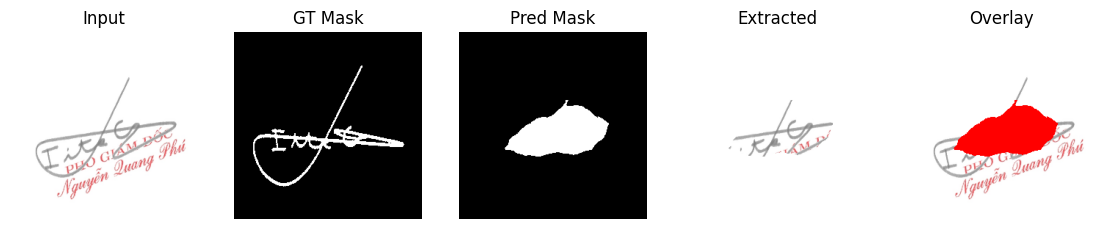

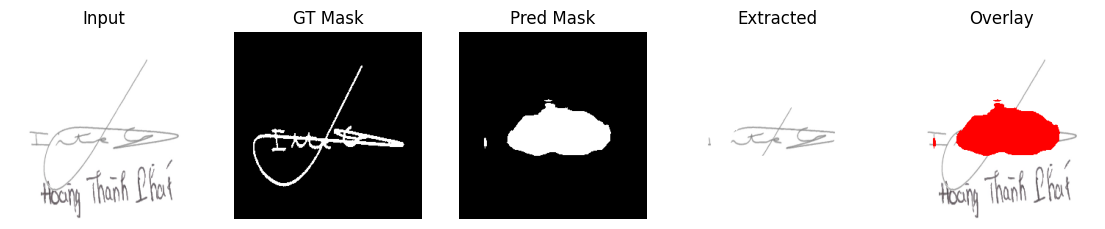

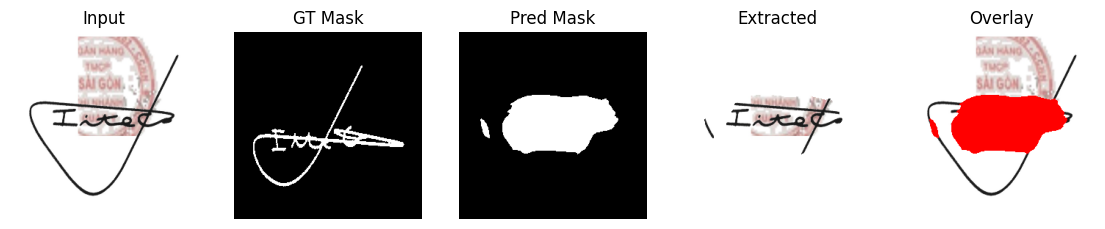

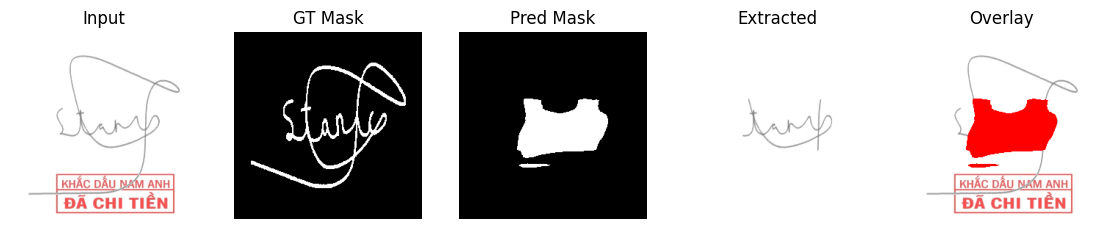

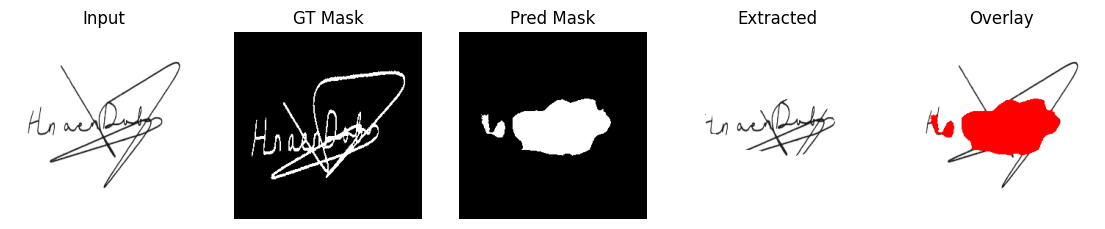

In [6]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import numpy as np
import cv2
import os

# pick random samples from TEST set
sample_df = test_df.sample(5, random_state=42)

for _, r in sample_df.iterrows():
    img_path = r["image_path"]
    mask_path = r["mask_path"]

    # load input
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # load GT mask
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_r = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # predict
    pred = model.predict(img_r[None, ...], verbose=0)[0, ..., 0]
    pred_bin = (pred > 0.5).astype(np.uint8) * 255

    # extract signature
    extracted = img_r.copy()
    extracted[pred_bin == 0] = 1.0  # white background

    # plot
    plt.figure(figsize=(14, 3))
    plt.subplot(1,5,1); plt.title("Input"); plt.imshow(img_r); plt.axis("off")
    plt.subplot(1,5,2); plt.title("GT Mask"); plt.imshow(gt_r, cmap="gray"); plt.axis("off")
    plt.subplot(1,5,3); plt.title("Pred Mask"); plt.imshow(pred_bin, cmap="gray"); plt.axis("off")
    plt.subplot(1,5,4); plt.title("Extracted"); plt.imshow(extracted); plt.axis("off")
    plt.subplot(1,5,5); plt.title("Overlay")
    overlay = img_r.copy()
    overlay[pred_bin > 0] = [1,0,0]
    plt.imshow(overlay); plt.axis("off")

    plt.show()